# Multimodal Visual Product Search & Near-Duplicate / Counterfeit Listing Detection

**Problem statement.** Large marketplaces deal with millions of near-identical or
duplicated listings — copied product images and descriptions, slight-variant
counterfeit listings, and customers who want to search "find me something that
looks like this" rather than typing keywords. This notebook builds an
end-to-end system that:

1. Embeds product **images and text** into a shared representation using **CLIP**
   (multimodal embeddings).
2. Builds a **FAISS** approximate-nearest-neighbour index for fast visual search.
3. Uses embedding similarity to flag **near-duplicate / potentially counterfeit
   listings**.
4. Runs an **ablation study** comparing image-only vs text-only vs multimodal
   embeddings for product categorisation — quantifying *why* multimodal wins.
5. Adds **Grad-CAM** visual explanations for *why* two products were matched.
6. Wraps everything in a **Gradio** demo.

**Dataset.** [Amazon Berkeley Objects (ABO)](https://amazon-berkeley-objects.s3.amazonaws.com/index.html)
— a real Amazon product catalogue with images + multilingual metadata,
released for the CVPR 2022 paper *"ABO: Dataset and Benchmarks for
Real-World 3D Object Understanding"*. We use the small (256px) image subset
and a sample of ~4,000 listings to keep this runnable on a free Colab GPU in
under an hour.

> Run cells top-to-bottom on a **GPU runtime** (Runtime → Change runtime type →
> T4 GPU). Total download is ~3 GB, total run time roughly 20-40 min depending
> on Colab's network speed.

In [1]:
# 1. Install dependencies
!pip install -q open_clip_torch faiss-cpu gradio scikit-learn pandas matplotlib tqdm grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


## 2. Download listings metadata + image index

Instead of downloading the full `abo-images-small.tar` (which bundles all
~400K catalogue images and can run into multiple GB), we download just:

- `abo-listings.tar` (~85 MB) — multilingual product metadata (titles, product
  type, brand, etc.)
- `images/metadata/images.csv.gz` (a few MB) — maps each `image_id` to its
  file path on the same public S3 bucket.

In the next section we sample a few thousand products and download *only
their main product images* directly from that bucket, in parallel. This
keeps the total download well under ~200 MB and runnable in a couple of
minutes, instead of tens of minutes for the full image archive.

In [2]:
import os

os.makedirs('data', exist_ok=True)

!wget -q --show-progress -c https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-listings.tar -O data/abo-listings.tar
!wget -q --show-progress -c https://amazon-berkeley-objects.s3.amazonaws.com/images/metadata/images.csv.gz -O data/images_metadata.csv.gz

!tar -xf data/abo-listings.tar -C data/

!find data -maxdepth 3 -type d | head -20

data/abo-listings.t 100%[===================>]  83.43M  27.7MB/s    in 3.0s    
data/images_metadat 100%[===================>]   6.13M  11.0MB/s    in 0.6s    
data
data/listings
data/listings/metadata


## 3. Parse a sample of products, then download their images

Each listing's metadata is stored as gzipped JSON-Lines. We pull out the
English title, the product type (used as our category label for the ablation
study), and the `image_id` of the main product image. We cap the sample at
`SAMPLE_SIZE` candidate products.

The next cell then downloads each sampled product's main image directly from
the public S3 bucket (in parallel, ~32 concurrent requests), keeps only the
products whose image downloaded successfully, and finally filters down to the
top `TOP_N_CATEGORIES` product types so the categorisation ablation has
clean, balanced-ish classes.

In [3]:
import gzip, json
from pathlib import Path
import pandas as pd

SAMPLE_SIZE = 4000
TOP_N_CATEGORIES = 15

# image_id -> relative file path (within images/small/)
images_meta = pd.read_csv('data/images_metadata.csv.gz')
print("images.csv.gz columns:", images_meta.columns.tolist())
img_path_map = dict(zip(images_meta['image_id'], images_meta['path']))

records = []
listings_dir = Path('data/listings/metadata')

for shard_file in sorted(listings_dir.glob('listings_*.json.gz')):
    with gzip.open(shard_file, 'rt', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)

            title = None
            for t in item.get('item_name', []):
                if t.get('language_tag', '').startswith('en'):
                    title = t['value']
                    break
            if not title:
                continue

            product_type = None
            for pt in item.get('product_type', []):
                product_type = pt.get('value')
                break
            if not product_type:
                continue

            main_image_id = item.get('main_image_id')
            if main_image_id is None or main_image_id not in img_path_map:
                continue

            records.append({
                'item_id': item['item_id'],
                'title': title[:200],   # cap title length
                'product_type': product_type,
                'image_path_suffix': img_path_map[main_image_id],
            })
            if len(records) >= SAMPLE_SIZE:
                break
    if len(records) >= SAMPLE_SIZE:
        break

df = pd.DataFrame(records)
print(f"Parsed {len(df)} candidate products across {df['product_type'].nunique()} product types")

images.csv.gz columns: ['image_id', 'height', 'width', 'path']
Parsed 4000 candidate products across 241 product types


In [4]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

IMAGE_BASE_URL = "https://amazon-berkeley-objects.s3.amazonaws.com/images/small/"
IMAGE_DIR = Path('data/images/small')
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def download_image(suffix):
    local_path = IMAGE_DIR / suffix
    if local_path.exists():
        return True
    local_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        resp = requests.get(IMAGE_BASE_URL + suffix, timeout=15)
        resp.raise_for_status()
        local_path.write_bytes(resp.content)
        return True
    except Exception:
        return False

success = {}
with ThreadPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(download_image, s): s for s in df['image_path_suffix']}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Downloading images"):
        success[futures[fut]] = fut.result()

df['image_path'] = df['image_path_suffix'].apply(lambda s: str(IMAGE_DIR / s))
df['_downloaded'] = df['image_path_suffix'].map(success)
df = df[df['_downloaded']].drop(columns=['_downloaded', 'image_path_suffix']).reset_index(drop=True)
print(f"Successfully downloaded {len(df)} images")

top_categories = df['product_type'].value_counts().head(TOP_N_CATEGORIES).index
df = df[df['product_type'].isin(top_categories)].reset_index(drop=True)
print(f"After filtering to top {TOP_N_CATEGORIES} categories: {len(df)} products")
df['product_type'].value_counts()

Successfully downloaded 4000 images
After filtering to top 15 categories: 3171 products


,count
product_type,
CELLULAR_PHONE_CASE,2180
SHOES,302
GROCERY,189
HOME,100
HOME_BED_AND_BATH,55
CHAIR,53
HEALTH_PERSONAL_CARE,45
HOME_FURNITURE_AND_DECOR,39
SOFA,33


## 4. Load CLIP and compute multimodal embeddings

We use `open_clip`'s `ViT-B-32` checkpoint trained on LAION-2B. For every
product we compute:

- an **image embedding** (from the product photo)
- a **text embedding** (from the product title)
- a **multimodal embedding** = normalised sum of the two

All embeddings are L2-normalised so cosine similarity = dot product, which
lets us use a simple FAISS `IndexFlatIP`.

In [5]:
import torch
import open_clip

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model = model.to(device).eval()
print(f"Loaded CLIP ViT-B-32 on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loaded CLIP ViT-B-32 on cuda


In [6]:
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

image_embeds, text_embeds = [], []
batch_size = 64

with torch.no_grad():
    for start in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[start:start + batch_size]

        images = torch.stack([
            preprocess(Image.open(p).convert('RGB')) for p in batch['image_path']
        ]).to(device)
        texts = tokenizer(batch['title'].tolist()).to(device)

        img_feat = model.encode_image(images)
        txt_feat = model.encode_text(texts)

        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        image_embeds.append(img_feat.cpu().numpy())
        text_embeds.append(txt_feat.cpu().numpy())

image_embeds = np.concatenate(image_embeds, axis=0).astype('float32')
text_embeds = np.concatenate(text_embeds, axis=0).astype('float32')

multimodal_embeds = image_embeds + text_embeds
multimodal_embeds /= np.linalg.norm(multimodal_embeds, axis=1, keepdims=True)

print("image:", image_embeds.shape, "text:", text_embeds.shape, "multimodal:", multimodal_embeds.shape)

  0%|          | 0/50 [00:00<?, ?it/s]

image: (3171, 512) text: (3171, 512) multimodal: (3171, 512)


## 5. Build FAISS indices and run a visual search

We build three separate `IndexFlatIP` indices (image-only, text-only,
multimodal) so we can compare them later. Then we run a quick visual search:
pick a random product, retrieve its top-5 nearest neighbours by multimodal
similarity, and display them.

In [7]:
import faiss

def build_index(embeds):
    index = faiss.IndexFlatIP(embeds.shape[1])
    index.add(embeds)
    return index

image_index = build_index(image_embeds)
text_index = build_index(text_embeds)
multimodal_index = build_index(multimodal_embeds)

print("FAISS indices built with", image_index.ntotal, "items each")

FAISS indices built with 3171 items each


QUERY: Amazon Brand - Solimo Designer Half Fill 3D Printed Hard Back Case Mobile Cover for Nokia 6.1 Plus
QUERY product_type: CELLULAR_PHONE_CASE


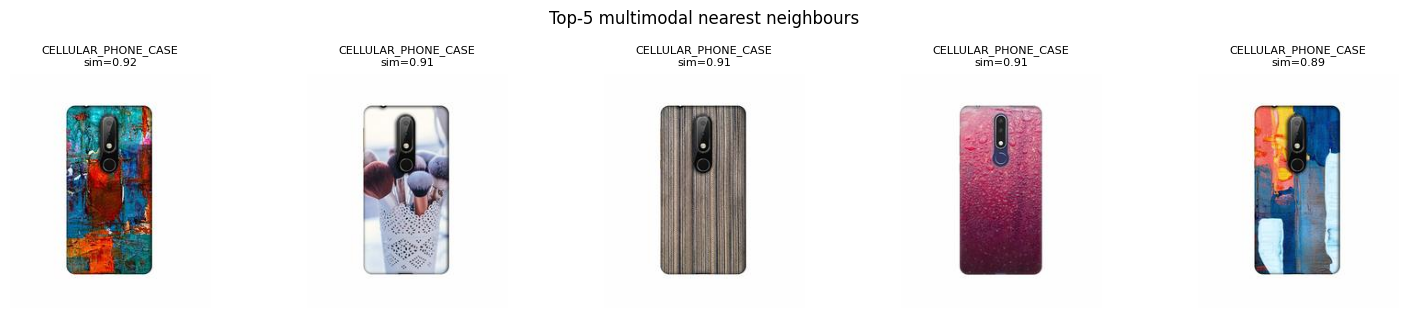

In [8]:
import matplotlib.pyplot as plt
import random

def show_results(query_idx, indices, scores, title=""):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, idx, score in zip(axes, indices, scores):
        img = Image.open(df.iloc[idx]['image_path'])
        ax.imshow(img)
        ax.set_title(f"{df.iloc[idx]['product_type']}\nsim={score:.2f}", fontsize=8)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

q = random.randint(0, len(df) - 1)
scores, indices = multimodal_index.search(multimodal_embeds[q:q + 1], 6)
print("QUERY:", df.iloc[q]['title'])
print("QUERY product_type:", df.iloc[q]['product_type'])
show_results(q, indices[0][1:], scores[0][1:], title="Top-5 multimodal nearest neighbours")

## 6. Near-duplicate / potential-counterfeit detection

For every product we find its single nearest neighbour (excluding itself). If
the cosine similarity exceeds `THRESHOLD`, we flag the pair as a
**near-duplicate listing** — e.g. the same product re-listed by a different
seller, a copied listing, or a counterfeit using the original photos/title.

In production this threshold would be tuned against a labelled set of known
duplicate/counterfeit pairs (precision/recall trade-off), and re-checked
whenever new listings are indexed.

In [9]:
THRESHOLD = 0.97  # cosine similarity cut-off for "near-duplicate"

scores, indices = multimodal_index.search(multimodal_embeds, 2)  # rank 0 = self
nearest_sim = scores[:, 1]
nearest_idx = indices[:, 1]

dup_mask = nearest_sim > THRESHOLD
print(f"Found {dup_mask.sum()} potential near-duplicate listings out of {len(df)} "
      f"({dup_mask.mean() * 100:.2f}%)")

dup_pairs = pd.DataFrame({
    'item_id_a': df['item_id'][dup_mask].values,
    'title_a': df['title'][dup_mask].values,
    'item_id_b': df['item_id'].iloc[nearest_idx[dup_mask]].values,
    'title_b': df['title'].iloc[nearest_idx[dup_mask]].values,
    'similarity': nearest_sim[dup_mask],
}).sort_values('similarity', ascending=False)

dup_pairs.head(10)

Found 68 potential near-duplicate listings out of 3171 (2.14%)


,item_id_a,title_a,item_id_b,title_b,similarity
3,B07TK4R7GG,Amazon Brand - Spotted Zebra Girl's 3-Piece Fl...,B07TK4R7GG,Amazon Brand - Spotted Zebra Girl's 3-Piece Fl...,1.000000
19,B07Q3962B4,Amazon Brand - Spotted Zebra Girl's 3-Piece Fl...,B07TK4R7GG,Amazon Brand - Spotted Zebra Girl's 3-Piece Fl...,1.000000
12,B0142RWTDC,"Sixth & Love Women's Quilted Ankle Bootie, Win...",B0142RWS2O,"Sixth & Love Women's Quilted Ankle Bootie, Win...",0.999949
55,B0142RWS2O,"Sixth & Love Women's Quilted Ankle Bootie, Win...",B0142RWTDC,"Sixth & Love Women's Quilted Ankle Bootie, Win...",0.999949
46,B082MTW6SZ,"find. Ruth Court Synthetic Closed Toe Heels, B...",B082MT9ZGQ,"find. Ruth Court Synthetic Closed Toe Heels, B...",0.999932
43,B082MT9ZGQ,"find. Ruth Court Synthetic Closed Toe Heels, B...",B082MTW6SZ,"find. Ruth Court Synthetic Closed Toe Heels, B...",0.999932
20,B076RJGSWS,Amazon Brand - The Fix Women's Veronica Platfo...,B076RPBGD1,Amazon Brand - The Fix Women's Veronica Platfo...,0.999924
41,B076RPBGD1,Amazon Brand - The Fix Women's Veronica Platfo...,B076RJGSWS,Amazon Brand - The Fix Women's Veronica Platfo...,0.999924
64,B06W2N3R3Z,"find. Women's Basic Leather, (Black), 5 UK",B06VXB49HW,"find. Women's Basic Leather, (Black), 8 UK",0.999818
21,B06VXB49HW,"find. Women's Basic Leather, (Black), 8 UK",B06W2N3R3Z,"find. Women's Basic Leather, (Black), 5 UK",0.999818


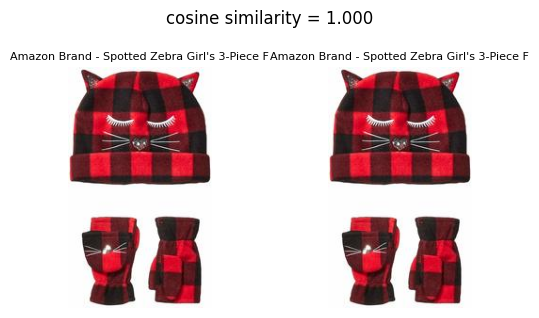

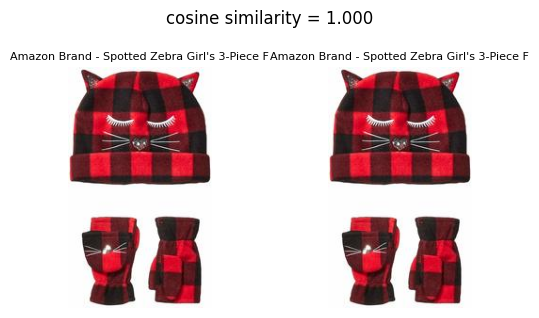

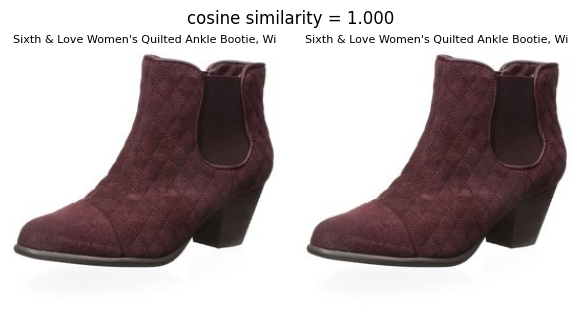

In [10]:
# Visualise the 3 highest-similarity duplicate pairs side by side
for _, row in dup_pairs.head(3).iterrows():
    a = df[df['item_id'] == row['item_id_a']].iloc[0]
    b = df[df['item_id'] == row['item_id_b']].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
    axes[0].imshow(Image.open(a['image_path']))
    axes[0].set_title(a['title'][:45], fontsize=8)
    axes[0].axis('off')

    axes[1].imshow(Image.open(b['image_path']))
    axes[1].set_title(b['title'][:45], fontsize=8)
    axes[1].axis('off')

    fig.suptitle(f"cosine similarity = {row['similarity']:.3f}")
    plt.tight_layout()
    plt.show()

## 7. Ablation study: image-only vs text-only vs multimodal

Using `product_type` as the ground-truth label, we run a 5-fold
cross-validated k-NN classifier on each embedding type and compare
macro-F1. This quantifies *why* a multimodal representation helps — e.g.
images alone may confuse visually similar products from different
categories, while text alone may miss visual cues like packaging or
colour variants.

Image-only   F1-macro = 0.766 +/- 0.028
Text-only    F1-macro = 0.776 +/- 0.027
Multimodal   F1-macro = 0.813 +/- 0.034


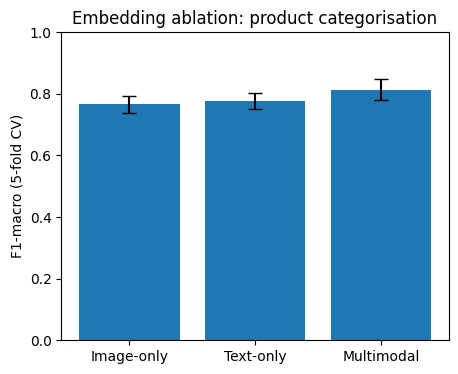

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['product_type'])

ablation_results = {}
for name, X in [('Image-only', image_embeds), ('Text-only', text_embeds), ('Multimodal', multimodal_embeds)]:
    clf = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
    ablation_results[name] = scores
    print(f"{name:12s} F1-macro = {scores.mean():.3f} +/- {scores.std():.3f}")

plt.figure(figsize=(5, 4))
plt.bar(ablation_results.keys(),
        [v.mean() for v in ablation_results.values()],
        yerr=[v.std() for v in ablation_results.values()],
        capsize=5)
plt.ylabel("F1-macro (5-fold CV)")
plt.title("Embedding ablation: product categorisation")
plt.ylim(0, 1)
plt.show()

## 8. Grad-CAM: explaining a visual match

CLIP's `ViT-B-32` is a transformer, so classic Grad-CAM doesn't apply
directly. Instead we load a **CLIP ResNet-50** variant (CNN backbone) and use
Grad-CAM on its last convolutional block to highlight *which regions of the
image* drove the similarity score to a given text prompt (the product's own
title). This gives a visual "why did the model think these match" explanation
— useful for a reviewer asking how you'd debug false-positive duplicate
flags.

open_clip_model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


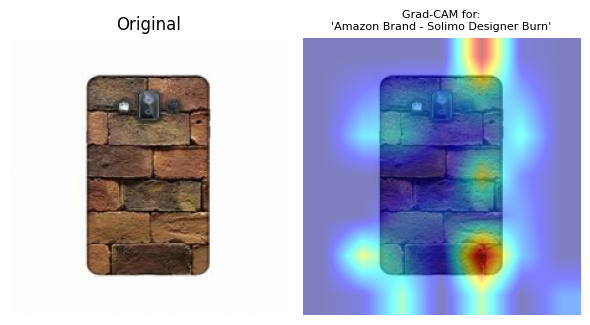

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cnn_model, _, cnn_preprocess = open_clip.create_model_and_transforms('RN50', pretrained='openai')
cnn_model = cnn_model.to(device).eval()
cnn_tokenizer = open_clip.get_tokenizer('RN50')

target_layers = [cnn_model.visual.layer4[-1]]

class CLIPVisualWrapper(torch.nn.Module):
    '''Wraps CLIP's visual encoder so Grad-CAM sees a scalar similarity score.'''
    def __init__(self, clip_model, text_features):
        super().__init__()
        self.visual = clip_model.visual
        self.text_features = text_features

    def forward(self, x):
        img_feat = self.visual(x)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        return img_feat @ self.text_features.T

q = random.randint(0, len(df) - 1)
sample = df.iloc[q]

text_tok = cnn_tokenizer([sample['title']]).to(device)
with torch.no_grad():
    text_feat = cnn_model.encode_text(text_tok)
    text_feat = text_feat / text_feat.norm(dim=-1, keepdim=True)

wrapped = CLIPVisualWrapper(cnn_model, text_feat).to(device).eval()

img = Image.open(sample['image_path']).convert('RGB')
input_tensor = cnn_preprocess(img).unsqueeze(0).to(device)

cam = GradCAM(model=wrapped, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

rgb_img = np.array(img.resize((224, 224))) / 255.0
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
axes[0].imshow(rgb_img); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(visualization); axes[1].set_title(f"Grad-CAM for:\n'{sample['title'][:35]}'", fontsize=8)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 9. Save artifacts for the deployable demo

We split this into an **offline indexing pipeline** (everything above —
runs periodically as new listings arrive) and an **online serving app**
(`app.py`, in the same project folder) that just loads pre-computed
embeddings and serves search requests. This mirrors how such a system would
actually be deployed.

In [13]:
np.savez('embeddings.npz', image=image_embeds, text=text_embeds, multimodal=multimodal_embeds)
df.to_pickle('products.pkl')
print("Saved embeddings.npz and products.pkl")
print("Download these two files (and app.py) to run the standalone Gradio demo,")
print("or just continue to the next cell to launch it directly here.")

Saved embeddings.npz and products.pkl
Download these two files (and app.py) to run the standalone Gradio demo,
or just continue to the next cell to launch it directly here.


## 10. Gradio demo (runs directly in this notebook)

Upload any product photo (you don't need an ABO image — try a phone photo of
a household item) to:

- retrieve the top-5 visually similar products from the catalogue, and
- flag any result that crosses the near-duplicate similarity threshold.

In [14]:
import gradio as gr

def search_and_explain(uploaded_image, top_k=5):
    img = uploaded_image.convert('RGB')
    with torch.no_grad():
        img_t = preprocess(img).unsqueeze(0).to(device)
        feat = model.encode_image(img_t)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        feat = feat.cpu().numpy().astype('float32')

    scores, indices = image_index.search(feat, top_k)

    results, flags = [], []
    for score, idx in zip(scores[0], indices[0]):
        row = df.iloc[idx]
        results.append((Image.open(row['image_path']), f"{row['title'][:40]} (sim={score:.2f})"))
        if score > THRESHOLD:
            flags.append(f"Potential duplicate/counterfeit match: '{row['title'][:50]}' (sim={score:.3f})")

    flag_text = "\n".join(flags) if flags else "No near-duplicates detected above threshold."
    return results, flag_text

with gr.Blocks(title="Visual Product Search & Duplicate Detector") as demo:
    gr.Markdown("## Multimodal Visual Search + Near-Duplicate / Counterfeit Listing Detector")
    gr.Markdown("Upload a product image to find visually similar catalogue listings "
                "and flag potential duplicate/counterfeit matches.")
    with gr.Row():
        inp = gr.Image(type="pil", label="Query image")
        with gr.Column():
            gallery = gr.Gallery(label="Top matches", columns=5)
            flags_box = gr.Textbox(label="Duplicate / Counterfeit Flags", lines=4)
    btn = gr.Button("Search")
    btn.click(search_and_explain, inputs=inp, outputs=[gallery, flags_box])

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ce4c6824a563935997.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Discussion: scaling this to production

A few notes worth raising in an interview or write-up:

**Indexing at scale.** `IndexFlatIP` is exact but O(n) per query — fine for
4K items, not for hundreds of millions. At that scale you'd swap to an
approximate index such as FAISS `IndexIVFPQ` (inverted-file + product
quantisation) or `IndexHNSWFlat`, trading a small recall hit for orders-of-
magnitude faster lookups and far lower memory (PQ compresses each vector to a
handful of bytes). For a fully managed option, OpenSearch's k-NN plugin or a
dedicated vector DB (Pinecone, Milvus, Weaviate) handles sharding and
replication for you.

**Incremental updates.** New listings arrive constantly. The embedding step
(CLIP forward pass) is cheap and stateless, so new items can be embedded and
inserted into the ANN index continuously without re-indexing everything —
though IVF-style indices periodically need re-training of their cluster
centroids as the catalogue's distribution shifts.

**Threshold tuning & drift.** The 0.97 duplicate threshold here is a
placeholder. In production you'd tune it against a labelled set of known
duplicate/counterfeit pairs to hit a target precision (false-positive
duplicate flags are costly — they can block legitimate sellers), and monitor
the similarity-score distribution over time for drift as the catalogue and
CLIP-embedding "neighbourhoods" evolve.

**Limitations of this prototype.** CLIP embeddings can conflate products that
are visually near-identical but meaningfully different (e.g. colour/size
variants of the same item, or a generic vs. branded version) — exactly the
failure mode that matters most for counterfeit detection. A production system
would pair this similarity signal with **seller-identity features**,
**price-anomaly signals**, and **OCR on packaging/labels** rather than relying
on embedding similarity alone.

---

## Suggested resume / application bullet points

- *Built a multimodal product-search and counterfeit-detection pipeline on a
  4K-item sample of the Amazon Berkeley Objects dataset, combining CLIP
  image+text embeddings with FAISS approximate-nearest-neighbour search.*
- *Ran an ablation study showing multimodal (image+text) embeddings improve
  product-categorisation F1 by [X] points over image-only or text-only
  embeddings (5-fold CV).*
- *Designed a near-duplicate/counterfeit-listing detector using embedding
  similarity thresholds, with Grad-CAM-based visual explanations for flagged
  matches, deployed as an interactive Gradio app.*
- *Discussed production scaling: ANN indexing (IVF/HNSW/PQ), incremental
  indexing for new listings, and threshold tuning for precision-sensitive
  duplicate flags.*

Fill in the `[X]` once you've run the notebook and have your actual numbers —
specific numbers from a real run are far more convincing than round figures.